In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

cmap = matplotlib.colormaps.get_cmap('magma')
size=12
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,      
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)

data_dir = 'raw_data_kymos/'

from SVD_analysis.src.data_settings import (sample_names, sample_names_cycling, sample_names_hilbert_6h,
                                            sample_colors, sample_dt, sample_dx, sample_temperatures, sample_somite_stage, sample_cropping_detailed)

from SVD_analysis.src.SVD_functions import get_input_kymo, kymo_svd


In [2]:
def init_df(sample_names, dt=None, dx=None, ss=None, colors=None, crop=None, temperatures=None,):
    tuples = []
    for exp, dates in sample_names.items():
        for date, locs in dates.items():
            for loc in locs:
                tuples.append((exp, date, loc))

    index = pd.MultiIndex.from_tuples(tuples, names=["Exp", "Date", "P"])
    df = pd.DataFrame(index=index, columns=["Temp", "color", "ss", "dt", "dx", "crop"]).sort_index()

    if temperatures is not None:
        for exp in df.index.levels[0]:
            df.loc[exp, "Temp"] = temperatures.get(exp)
    if colors is not None:
        for exp in df.index.levels[0]:
            df.loc[exp, "color"] = colors.get(exp)
    if dt is not None:
        for exp in df.index.levels[0]:
            df.loc[exp, "dt"] = dt.get(exp)
    if dx is not None:
        for exp in df.index.levels[0]:
            df.loc[exp, "dx"] = dx.get(exp)
    if ss is not None:
        for exp in df.index.levels[0]:
            df.loc[exp, "ss"] = ss.get(exp)


    if crop is not None:
        if isinstance(crop, int):
            df["crop"] = crop
        else:
            for exp, dates in sample_names.items():
                for date, locs in dates.items():
                    for i, loc in enumerate(locs):
                        try:
                            df.loc[(exp, date, loc), "crop"] = int(crop[exp][date][i])
                        except Exception:
                            df.loc[(exp, date, loc), "crop"] = np.nan
    return df

# Init dataframes

In [3]:

df = init_df(sample_names, dt=sample_dt, dx=sample_dx, ss=sample_somite_stage, colors=sample_colors,
             crop=sample_cropping_detailed, temperatures=sample_temperatures)
df.head(3)

Temp    color  ss    dt    dx crop
Exp         Date     P                                    
TE_22C_14ss 20210301 1  22.0  #31688e  14  10.0  1.38   10
                     2  22.0  #31688e  14  10.0  1.38   10
                     4  22.0  #31688e  14  10.0  1.38   10

In [4]:
df_cycling = init_df(sample_names_cycling, dt=sample_dt, dx=sample_dx, ss=sample_somite_stage, colors=sample_colors,
             crop=0, temperatures=None)

df_hilbert = init_df(sample_names_hilbert_6h, dt=sample_dt, dx=sample_dx, ss=sample_somite_stage, colors=sample_colors,
             crop=10, temperatures=sample_temperatures)

In [5]:
temp_20210604 = pd.read_csv(data_dir+'20210604_temperature.csv', names=('mins', 'time', 'left', 'right', 'diff l/r', 'diff l', 'diff r'))
temp_20210604['avg temp'] = (temp_20210604['left'] + temp_20210604['right'])/2.
temp_20210604.head(3)

temp_20210605 = pd.read_csv(data_dir+'20210605_temperature.csv', names=('mins', 'time', 'left', 'right', 'diff l/r', 'diff l', 'diff r'))
temp_20210605['avg temp'] = (temp_20210605['left'] + temp_20210605['right'])/2.

# Chronic

TE_32C_14ss_5dt 20220429 2


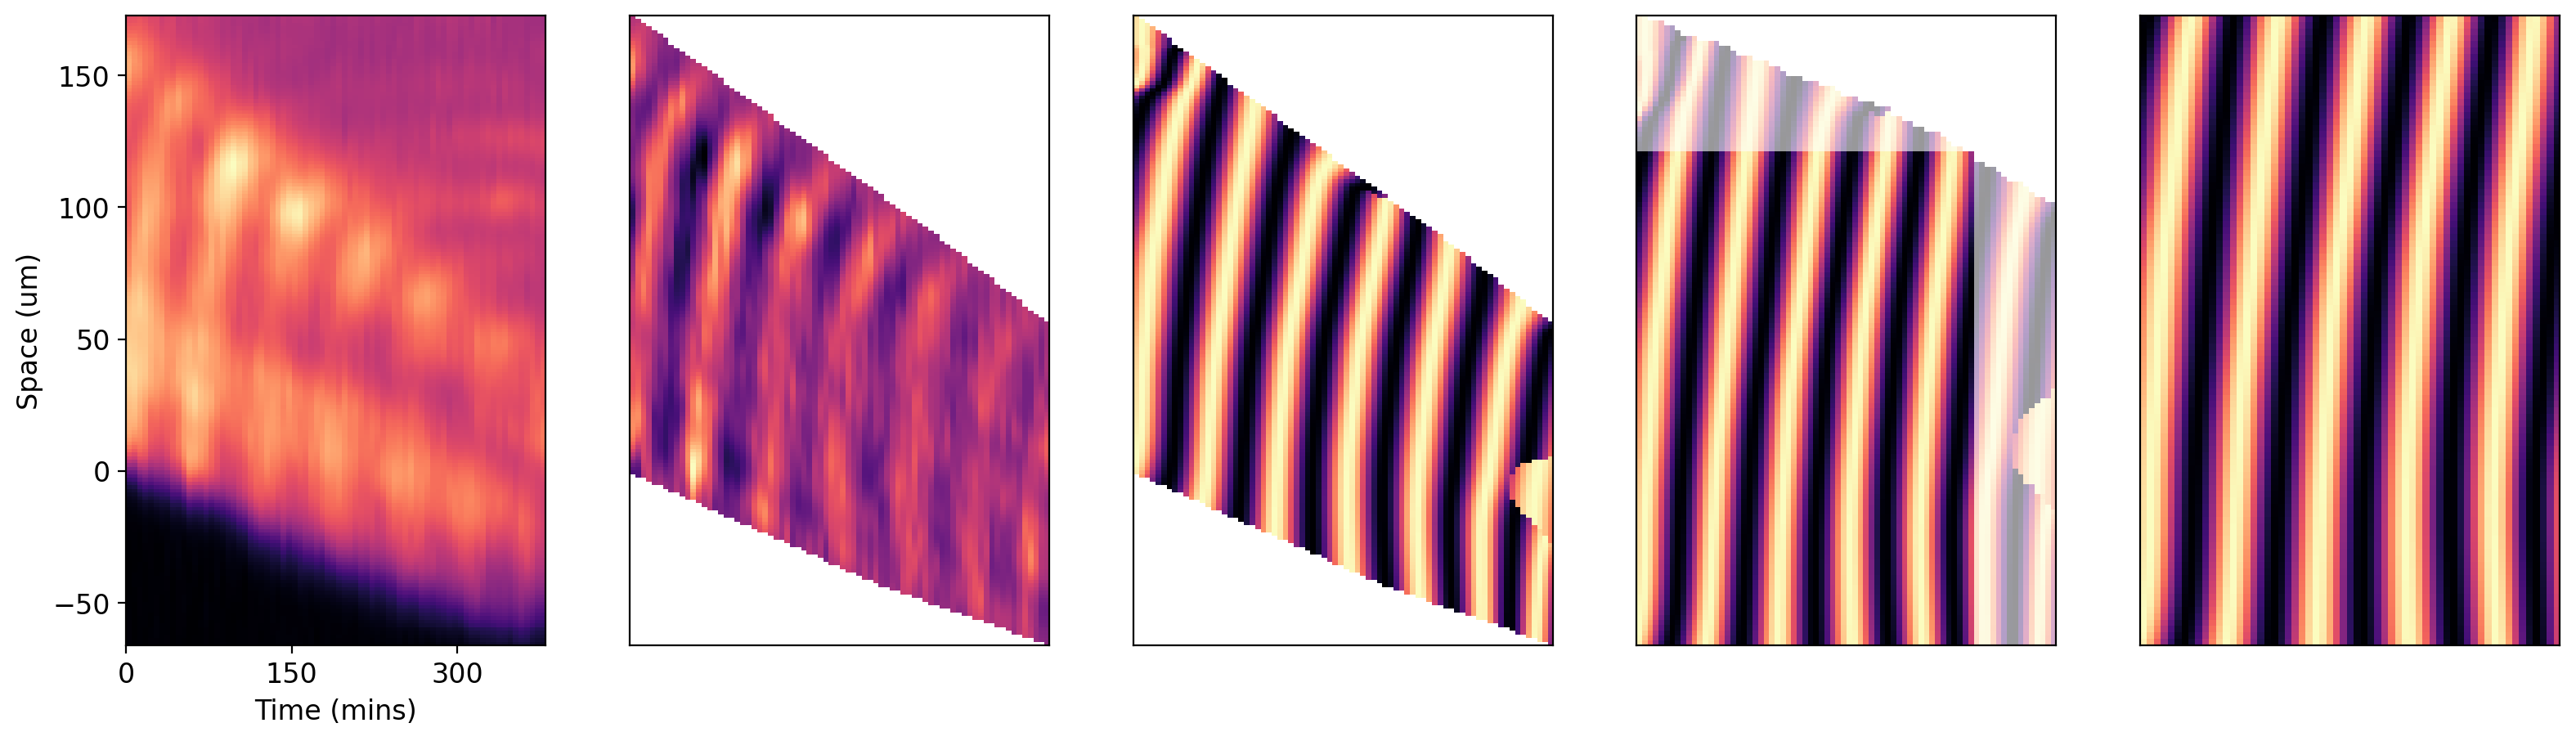

s0: 686.0813740650923 | s1: 78.14236043323723 | sum s: 772.3854472335081
T0: 62.33822321389423 +- 0.5597985823545102


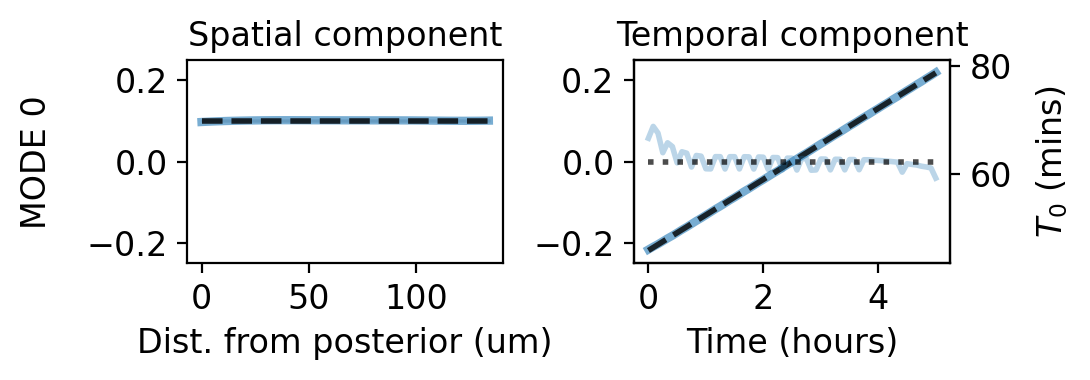

[ 6.18926518e-01  2.65007403e-02 -1.44412876e-01  1.21922717e+02]
Spatial pars: [ 6.19000e-01  2.70000e-02 -1.44000e-01  1.21923e+02]  with errors [2.600e-02 1.000e-03 2.000e-03 2.658e+00]


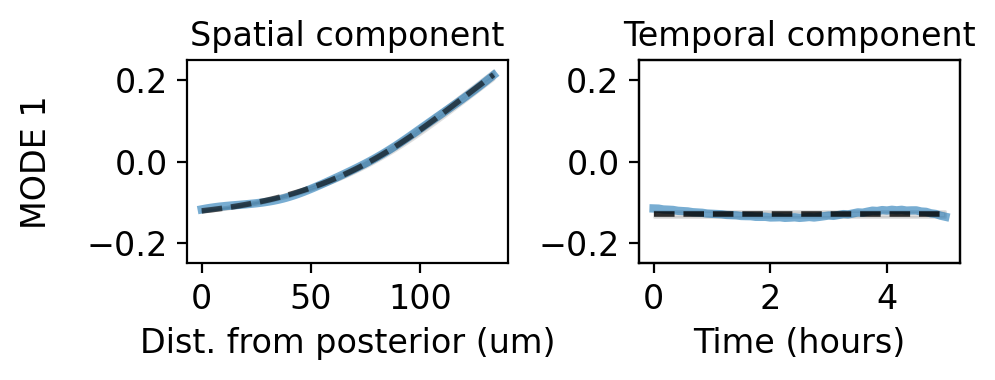

psm0: 173.88


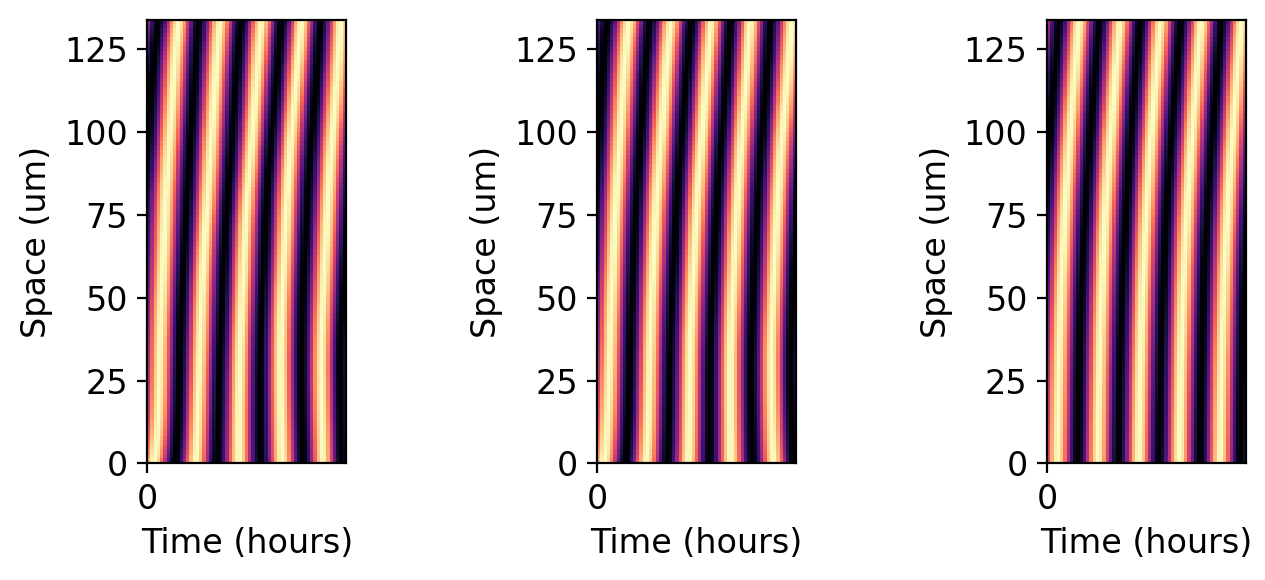

In [6]:
index = df.index[31] # 15, 25, 31
print(*index)
K, mask, phi_full, t0 = get_input_kymo(data_dir, *index, df, preregistered=False, naming='default', crop=None, extrapolate=False, output=1)
res = kymo_svd(K, mask, *index, df, plot_matrices=False, plot_modes=0, n_modes=2, write=0, weighted_fit=0, cycling=0, save_dir='SVD_results_sigmoid', output=1, sigmoid=1)
# deltaphi_analysis(phi_full, res, *index, df)

# Fit all

In [7]:
for index in df.index[:]:
    print(*index)
    K, mask, phi_full, t0 = get_input_kymo(data_dir, *index, df, preregistered=False, naming='default', crop=None, extrapolate=False, output=0)
    res = kymo_svd(K, mask, *index, df, plot_matrices=False, plot_modes=2, n_modes=2, write=True, weighted_fit=0, cycling=0, save_dir='SVD_results', output=0, sigmoid=1)


TE_22C_14ss 20210301 1
[ 7.32901387e-01  1.74396257e-02 -1.75442886e-01  1.49416672e+02]
psm0: 224.93999999999997
TE_22C_14ss 20210301 2
[ 5.99353629e-01  1.97321962e-02 -1.74202328e-01  1.25439544e+02]
psm0: 202.85999999999999
TE_22C_14ss 20210301 4
[ 5.90708241e-01  2.32389116e-02 -1.66886987e-01  1.15566601e+02]
psm0: 206.99999999999997
TE_22C_14ss 20210301 5
[ 3.82543803e-01  2.31505084e-02 -1.06374923e-01  1.57185454e+02]
psm0: 220.79999999999998
TE_22C_14ss 20210301 6
[ 5.58661188e-01  2.74108291e-02 -1.39434036e-01  1.17997435e+02]
psm0: 197.33999999999997
TE_22C_14ss 20210301 7
[ 6.07178303e-01  3.42973988e-02 -8.49266151e-02  1.57782679e+02]
psm0: 206.99999999999997
TE_22C_15ss 20200817 1
[ 3.62270919e-01  4.49203727e-02 -1.10247415e-01  9.89260988e+01]
psm0: 165.6
TE_22C_15ss 20200817 4
[ 8.60070387e-01  3.54240552e-02 -1.40720467e-01  1.10061345e+02]
psm0: 151.79999999999998
TE_22C_15ss 20200817 6
[ 4.11963344e-01  4.46442025e-02 -1.14194115e-01  9.62097604e+01]
psm0: 168.35

In [8]:
df.head()

Temp    color  ss    dt    dx crop    psm0   psm_f  \
Exp         Date     P                                                       
TE_22C_14ss 20210301 1  22.0  #31688e  14  10.0  1.38   10  224.94  151.80   
                     2  22.0  #31688e  14  10.0  1.38   10  202.86  149.04   
                     4  22.0  #31688e  14  10.0  1.38   10  207.00  138.00   
                     5  22.0  #31688e  14  10.0  1.38   10  220.80  198.72   
                     6  22.0  #31688e  14  10.0  1.38   10  197.34  138.00   

                                 s0          s1  ...   Amp err     alpha  \
Exp         Date     P                           ...                       
TE_22C_14ss 20210301 1  1725.900905   94.948219  ...  1.943644  0.002093   
                     2  1806.108523  111.762823  ...   0.58334  0.002709   
                     4  1707.315811  114.274217  ...  1.113469  0.002375   
                     5    677.67317  125.135523  ...  0.342765  0.004158   
                     6  1788.534287  124.283703  ...   1.92667  0.003781   

                       alpha err   alpha_c alpha_c err  lambda_tb  \
Exp         Date     P                                              
TE_22C_14ss 20210301 1  0.000205  0.291979    0.029212  16.742302   
                     2   0.00016  0.357818     0.02255  18.133729   
                     4  0.000224  0.319354    0.030479  13.742189   
                     5  0.000178  0.545061    0.030212  23.544227   
                     6  0.000383  0.485386    0.050074  17.707822   

                       lambda_tb err   lambda_f lambda_f err resid_cycle  
Exp         Date     P                                                    
TE_22C_14ss 20210301 1      0.402372  26.172273      0.55106    4.970775  
                     2      0.408305  23.883514     0.529227    3.830441  
                     4      0.227838  22.006789     0.346212    3.932412  
                     5      0.852801   30.21297     1.083149    3.360199  
                     6        0.3599  24.094514     0.483562    6.232484  

[5 rows x 39 columns]

In [9]:
df.to_csv('SVD_results/result_parameters_chronic.csv')

# Wavelet cycling (24h and 12h)


TE_21-27C12h_15ss 20210604 1


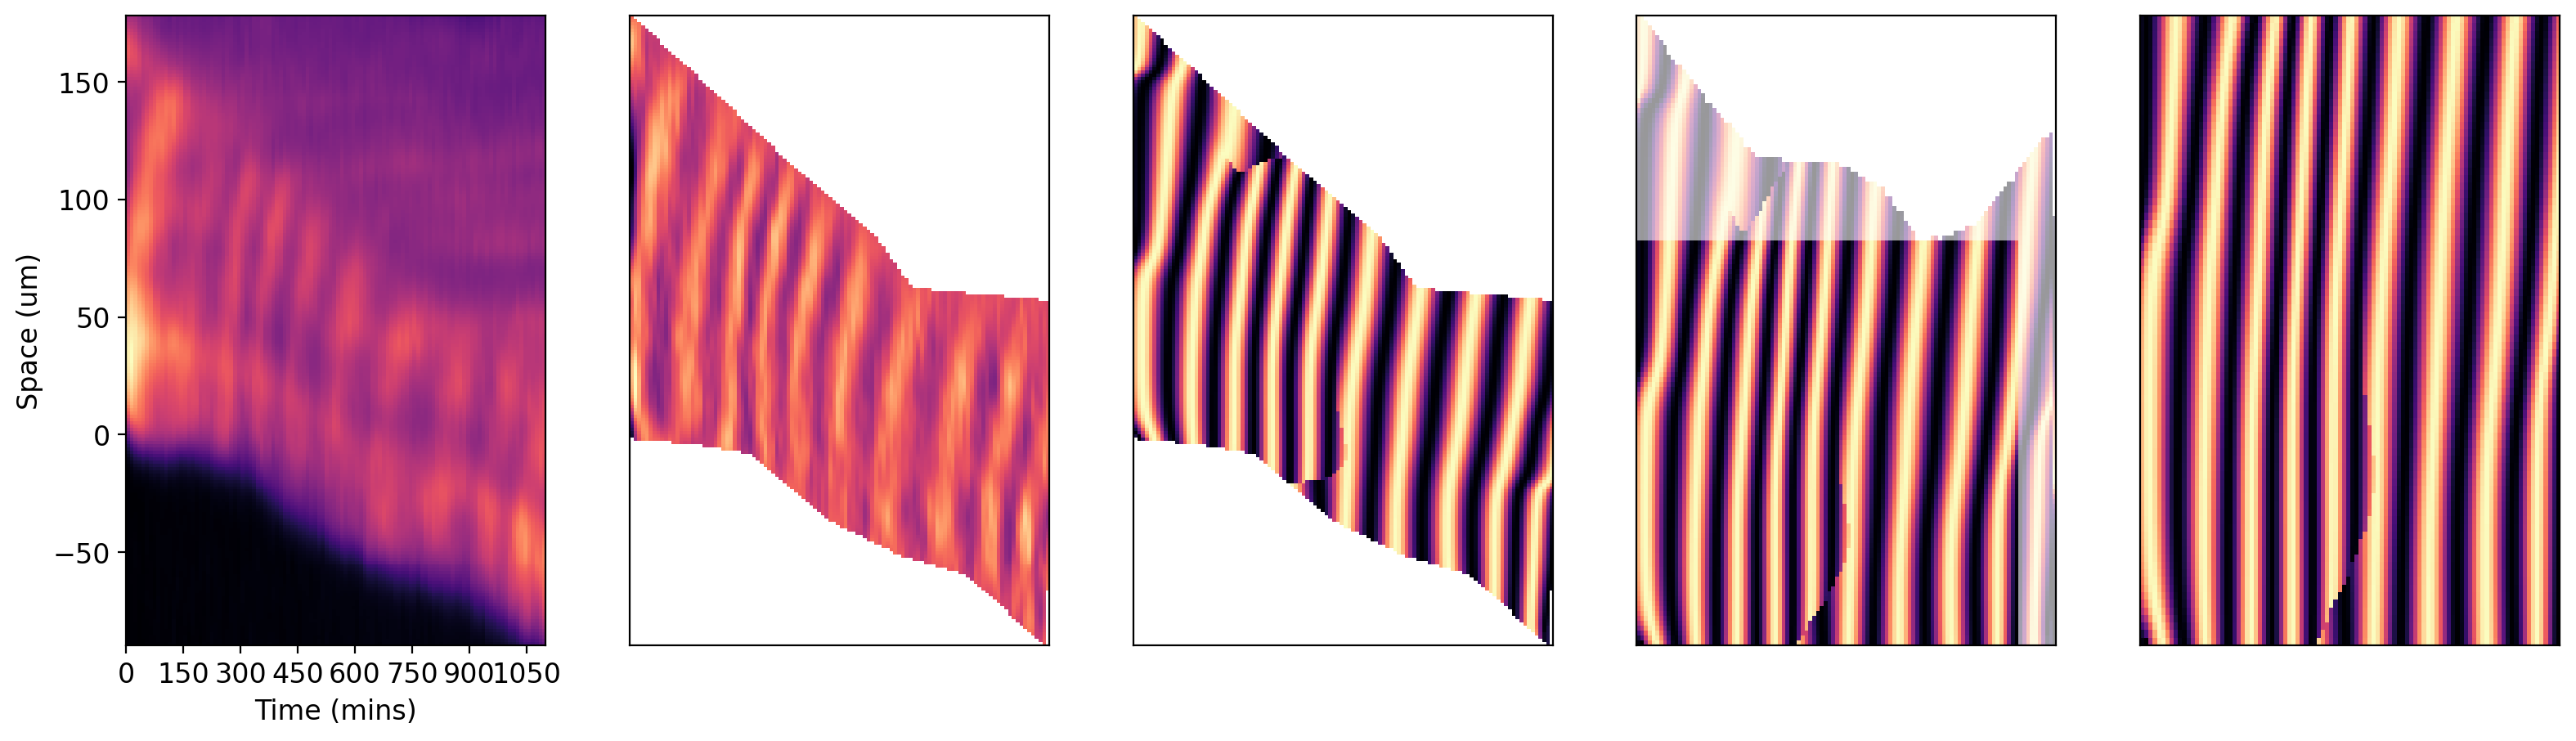

s0: 1457.7327955956466 | s1: 94.32884575782224 | sum s: 1599.818140810481
T0: 113.57103598685265 +- 1.332973851632934


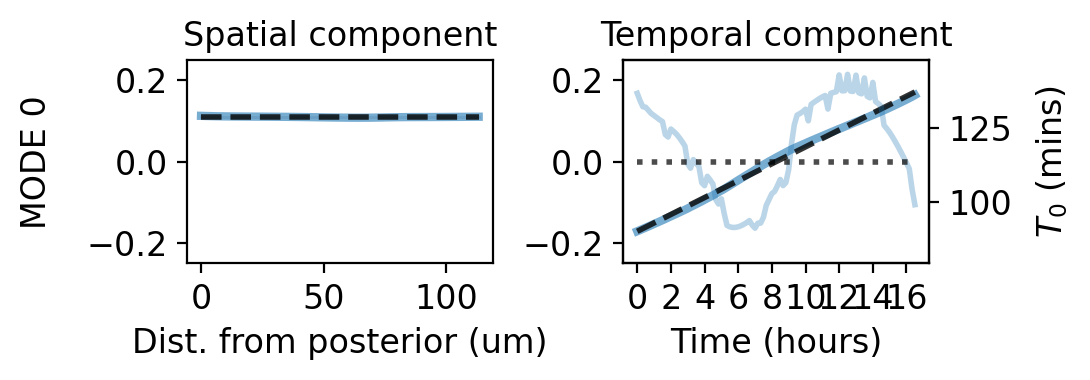

[ 6.60712977e-01  3.25734655e-02 -1.51104526e-01  1.02822333e+02]
Spatial pars: [ 6.61000e-01  3.30000e-02 -1.51000e-01  1.02822e+02]  with errors [6.800e-02 2.000e-03 6.000e-03 5.432e+00]


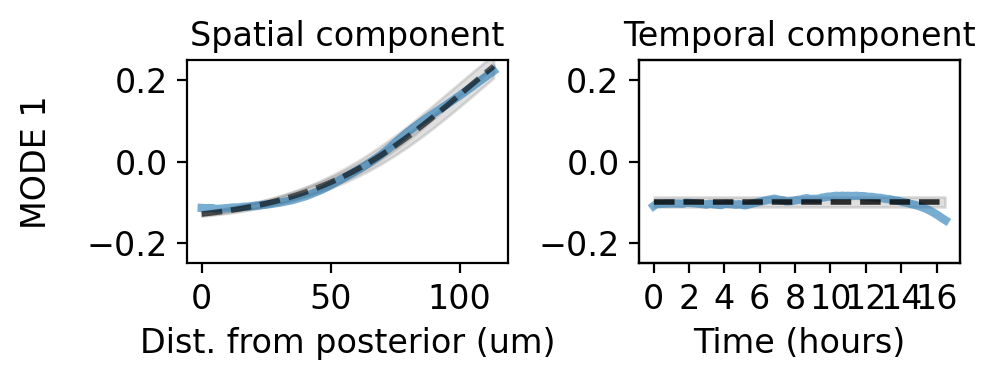

psm0: 179.39999999999998


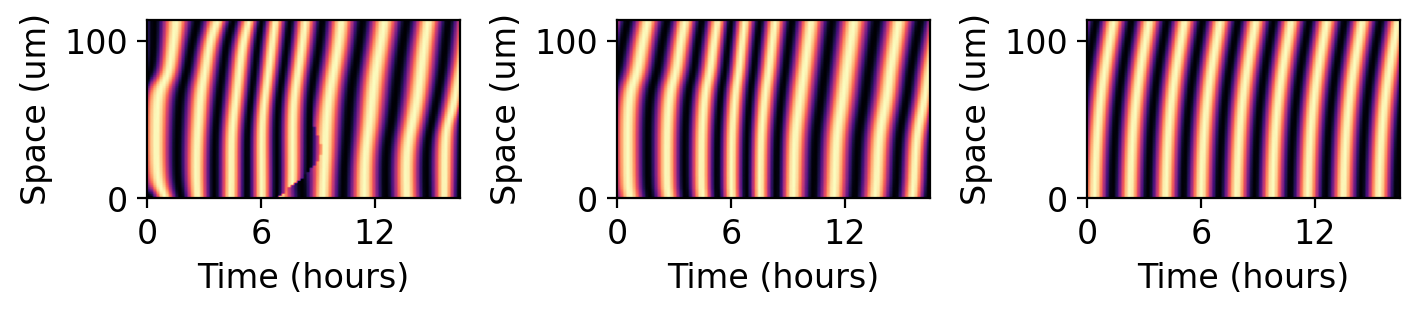

In [10]:
index = df_cycling.index[0]
print(*index)
K, mask, phi_full, t0 = get_input_kymo(data_dir, *index, df_cycling, preregistered=False, naming='default', crop=10, extrapolate=False, output=1)
res = kymo_svd(K, mask, *index, df_cycling, plot_matrices=False, plot_modes=2, n_modes=2, write=0, weighted_fit=0, cycling=0, save_dir='SVD_results_sigmoid', output=1, sigmoid=1)

In [11]:
data_dir = 'raw_data_kymos/'
for index in df_cycling.index[:]:
    print(*index)
    K, mask, phi_full, t0 = get_input_kymo(data_dir, *index, df_cycling, preregistered=False, naming='default', crop=10, extrapolate=False, output=0)
    res = kymo_svd(K, mask, *index, df_cycling, plot_matrices=False, plot_modes=2, n_modes=2, write=1, weighted_fit=0, cycling=0, save_dir='SVD_results', output=0, sigmoid=1)


TE_21-27C12h_15ss 20210604 1
[ 6.60712977e-01  3.25734655e-02 -1.51104526e-01  1.02822333e+02]
psm0: 179.39999999999998
TE_21-27C12h_15ss 20210604 2
[ 5.18470281e-01  3.03332804e-02 -2.32711604e-01  6.22411387e+01]
psm0: 160.07999999999998
TE_21-27C12h_15ss 20210604 3
[ 9.97435656e-01  4.38359054e-02 -9.81249365e-02  1.24450479e+02]
psm0: 182.16
TE_21-27C12h_15ss 20210605 1
[ 5.42533368e-01  3.62750920e-02 -1.17854304e-01  1.07694814e+02]
psm0: 206.99999999999997
⚠ Fit residual > 15%
TE_21-27C12h_15ss 20210605 2
[ 9.93577456e-01  1.70354966e-02 -3.12115478e-01  1.03760504e+02]
⚠ Poor mode fit
psm0: 182.16
⚠ Fit residual > 15%
TE_21-27C12h_15ss 20210605 3
[ 4.72084590e-01  4.15238921e-02 -1.27592682e-01  9.12491869e+01]
psm0: 189.05999999999997
TE_21-27C12h_15ss 20210605 4
[ 7.29604651e-01  3.21024948e-02 -1.97414976e-01  8.46747489e+01]
psm0: 153.17999999999998
TE_21-27C12h_15ss 20210605 5
[ 3.88638125e-01  4.88148536e-02 -8.74650738e-02  1.16053846e+02]
psm0: 176.64
TE_21-27C12h_15ss 

In [12]:
df_cycling.to_csv('SVD_results/result_parameters_cycling.csv')

# Hilbert cycling

('hilbert/6h', '221128', 1)


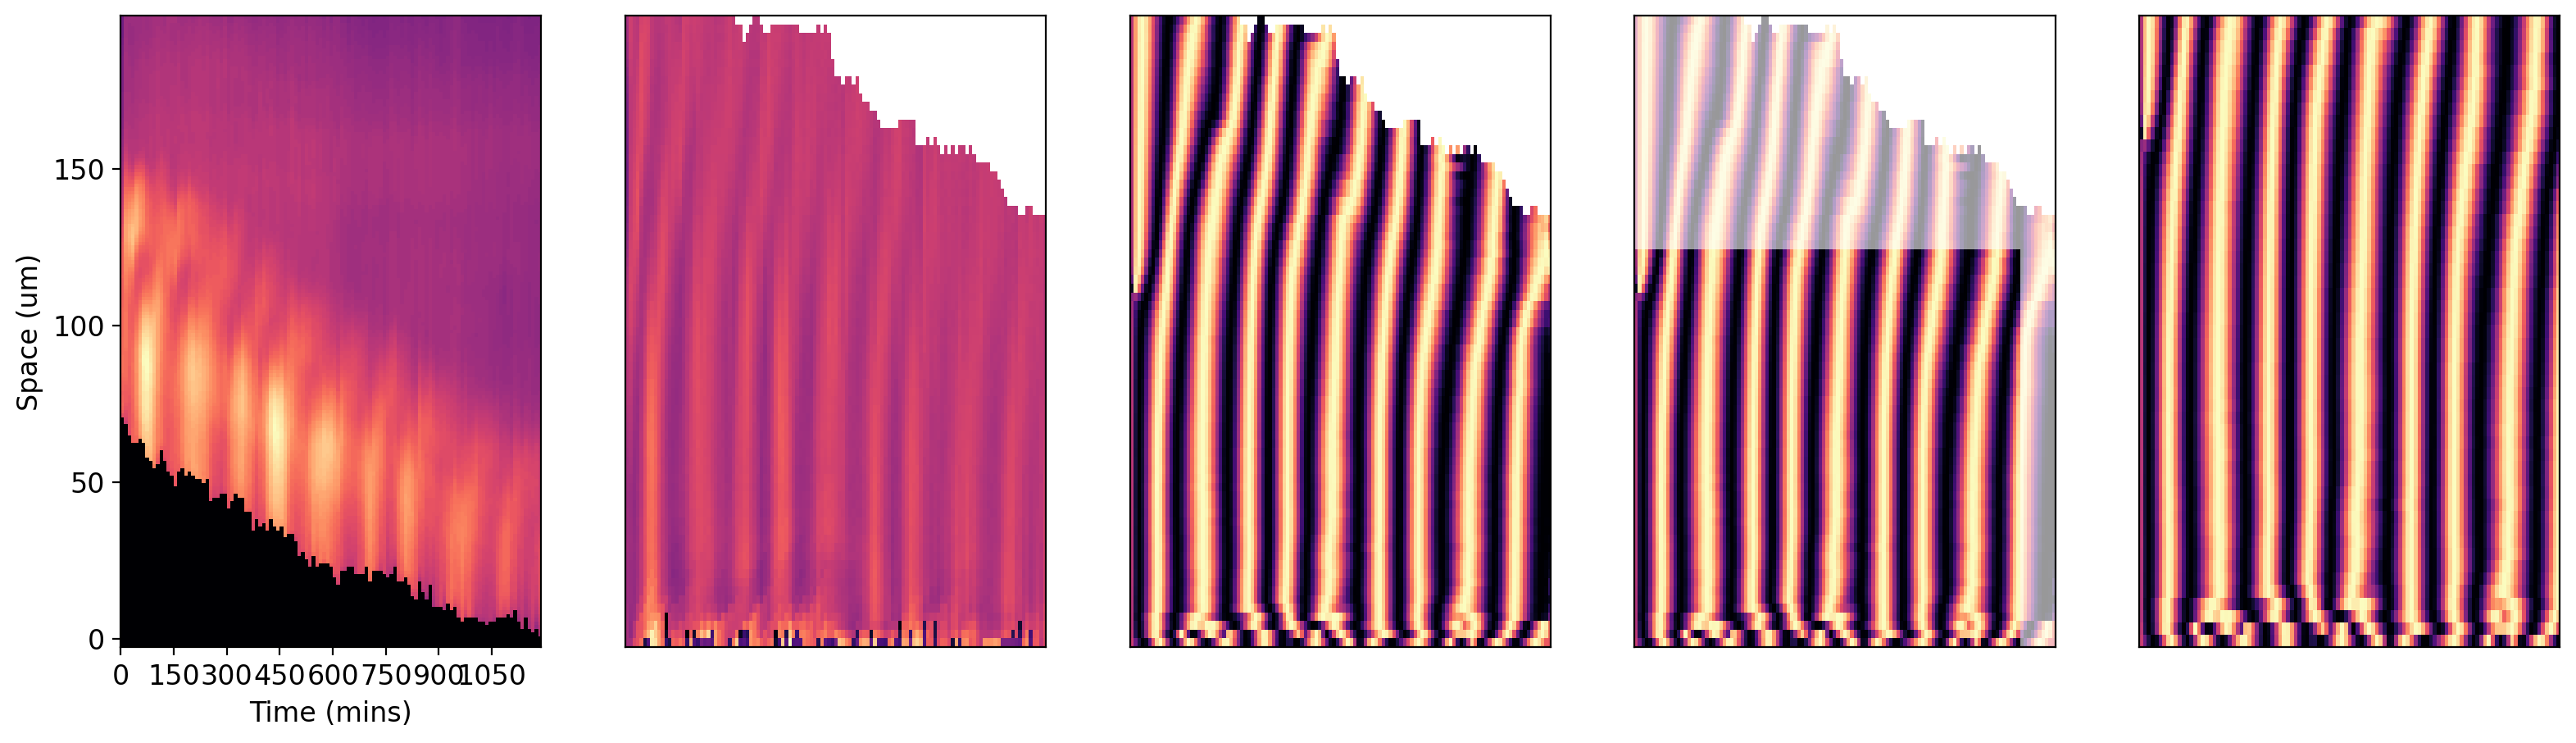

s0: 1110.2197678903772 | s1: 54.83660608146661 | sum s: 1188.29207831988
T0: 125.63573833770691 +- 1.2186430767023941
Period amplitude: 42.98149210121727 mins


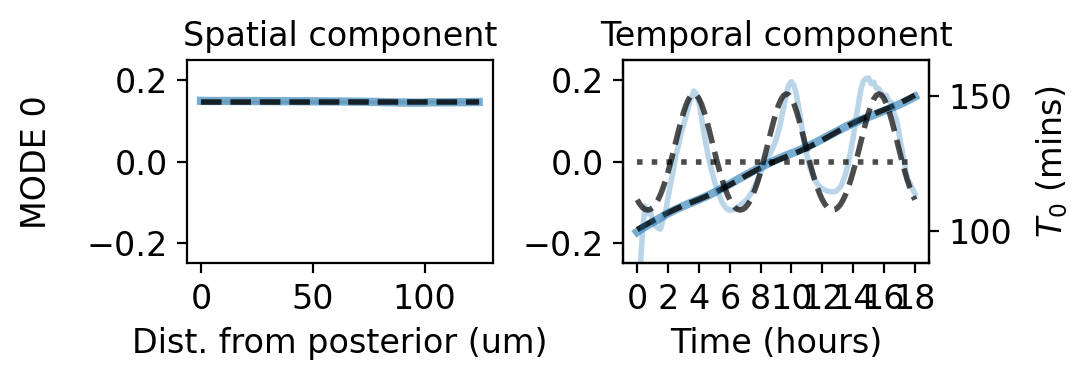

[ 1.24157667e+00  3.88500473e-02 -1.39471465e-01  1.32723477e+02]
Spatial pars: [ 1.24200e+00  3.90000e-02 -1.39000e-01  1.32723e+02]  with errors [2.9700e-01 4.0000e-03 6.0000e-03 1.0505e+01]


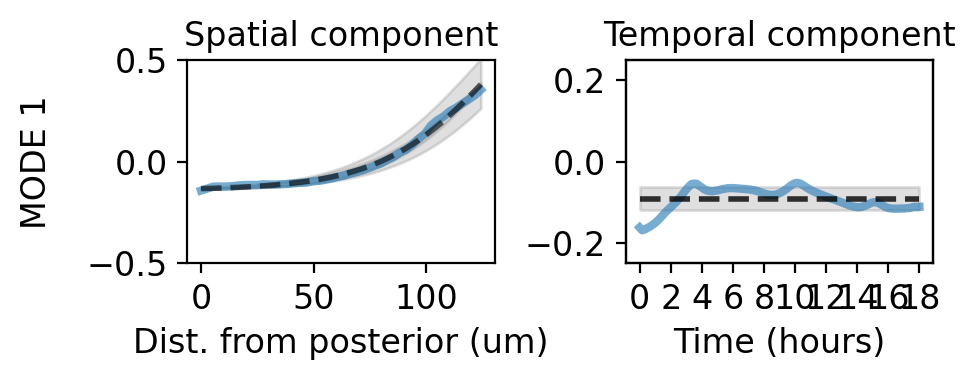

psm0: 204.23999999999998


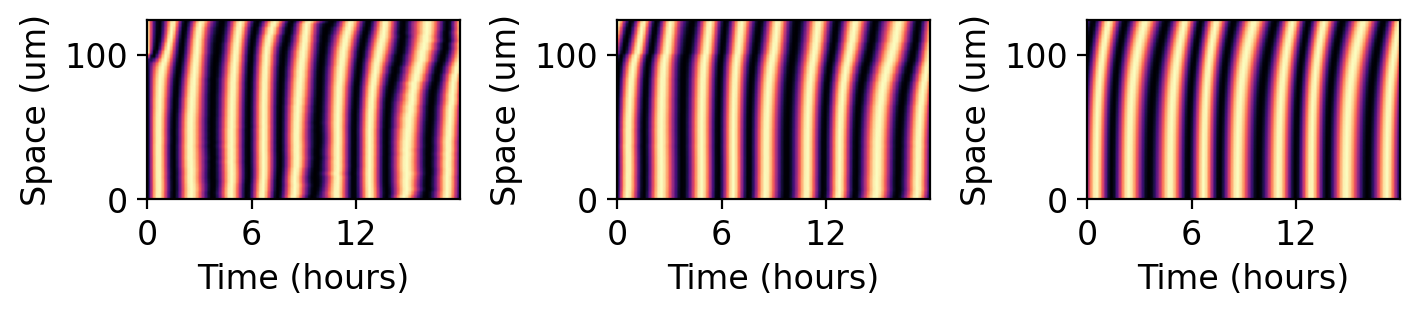

In [13]:
index = df_hilbert.index[0]
print(index)

K, mask, phi_full, t0 = get_input_kymo(data_dir, *index, df_hilbert, preregistered=True, naming='hilbert', crop=10, extrapolate=False, output=1, dx=1.38*2)
res = kymo_svd(K[:-5, :], mask, *index, df_hilbert, t0=t0, plot_matrices=False, plot_modes=2, n_modes=2, write=0, weighted_fit=False, cycling=True, save_dir='SVD_results_sigmoid', output=1, sigmoid=1)

In [14]:
for index in df_hilbert.index[:]:
    if index[0] == 'hilbert/6h':
        print(index)
        # if index[1:] == ('221129', 2):
        #     continue
        # if index[1:] == ('221128', 5):

        K, mask, phi_full, t0 = get_input_kymo(data_dir, *index, df_hilbert, preregistered=True, naming='hilbert', crop=10, extrapolate=False, output=0, dx=1.38*2)
        res = kymo_svd(K[:-5, :], mask, *index, df_hilbert, t0=t0, plot_matrices=False, plot_modes=2, n_modes=2, write=True, weighted_fit=False, cycling=True, save_dir='SVD_results_sigmoid', output=0, sigmoid=1)

('hilbert/6h', '221128', 1)
[ 1.24157667e+00  3.88500473e-02 -1.39471465e-01  1.32723477e+02]
psm0: 204.23999999999998
('hilbert/6h', '221128', 2)
[ 5.88407937e-01  2.89700559e-02 -1.62556273e-01  1.25832846e+02]
psm0: 190.44
('hilbert/6h', '221128', 3)
[ 8.02948410e-01  3.47372744e-02 -1.52989356e-01  1.24304508e+02]
psm0: 237.35999999999999
('hilbert/6h', '221128', 6)
[ 6.71097374e-01  3.46159271e-02 -1.29021160e-01  1.39322295e+02]
psm0: 215.27999999999997
('hilbert/6h', '221129', 1)
[ 9.90412552e-01  2.58342671e-02 -1.50309824e-01  1.59848151e+02]
psm0: 218.04
('hilbert/6h', '221129', 3)
[ 1.39512103e+00  4.04279817e-02 -1.28216744e-01  1.39682460e+02]
psm0: 195.95999999999998
('hilbert/6h', '221129', 4)
[ 8.42273975e-01  3.91038275e-02 -1.29573960e-01  1.31180384e+02]
psm0: 209.76
('hilbert/6h', '221129', 5)
[ 1.36149870e+00  3.46011076e-02 -1.23141956e-01  1.59993784e+02]
psm0: 206.99999999999997


In [15]:
df_hilbert.to_csv('SVD_results/result_parameters_cycling_6h.csv')